# 02 — Exploratory Data Analysis

**Input:** `train.parquet` from notebook 01

**Output:** `eda_findings.json` — hypotheses carried into feature engineering

**Governing rule:** every distribution, outlier decision, and correlation in this notebook is computed on training data only. A preprocessing decision shaped by patterns in the test set is leakage even when the influence was accidental.

**The one exception, with a precise boundary.** Adversarial validation in Part 6 reads the test set's *features* and never its *labels*. Learning from unlabelled test features is transductive learning, which is legitimate and standard. Using test labels, or letting the test target influence a preprocessing choice, is leakage. The code enforces this by dropping the target column in the same expression that loads the file, so no variable in this notebook ever holds a test label.

---

## Setup

In [1]:
# Restart the kernel after this cell before running the rest.
%pip install -q --force-reinstall --no-deps git+https://github.com/rbennum/telco-churn.git
%pip install -q pyarrow

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from telco_churn.config import (
    RANDOM_SEED,
    TARGET,
    OUT_DIR,
    describe_paths,
    ensure_out_dir,
    find_artifact,
)
from telco_churn.business import (
    COST_ASSUMPTIONS,
    breakeven_effectiveness,
    offer_cost,
    optimal_threshold,
    value_at_risk,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 11

ensure_out_dir()
print(f"seed {RANDOM_SEED} | target {TARGET}")
print(describe_paths())

seed 29 | target Churn
ON_KAGGLE = True
OUT_DIR   = /kaggle/working
raw csv   = NOT FOUND
train.parquet        = /kaggle/input/notebooks/benranum/churn-proj-01-ingest/train.parquet
test.parquet         = /kaggle/input/notebooks/benranum/churn-proj-01-ingest/test.parquet
ingest_manifest.json = /kaggle/input/notebooks/benranum/churn-proj-01-ingest/ingest_manifest.json


In [3]:
# Inputs come from wherever notebook 01's output was mounted; outputs go to
# OUT_DIR. On Kaggle those are never the same directory, because everything
# under /kaggle/input is read-only.
TRAIN_PATH = find_artifact("train.parquet")
print(f"reading {TRAIN_PATH}")
train = pd.read_parquet(TRAIN_PATH)

# Print shape on both sides of every handoff. A mismatch against the manifest
# means you are reading a stale artifact, and you want to know that now rather
# than after the metrics have had a chance to mislead you.
try:
    manifest = json.loads(find_artifact("ingest_manifest.json").read_text())
    print(f"manifest expects : {manifest['train_rows']} rows x "
          f"{manifest['n_features'] + 1} cols")
except FileNotFoundError:
    manifest = None
    print("manifest not found — cannot cross-check shape")

print(f"loaded           : {train.shape[0]} rows x {train.shape[1]} cols")
if manifest:
    assert len(train) == manifest["train_rows"], "Stale train.parquet — re-run notebook 01"

y = train[TARGET]
X = train.drop(columns=[TARGET])

NUM_COLS = X.select_dtypes(include=np.number).columns.tolist()
CAT_COLS = [c for c in X.columns if c not in NUM_COLS]

print(f"\nnumeric ({len(NUM_COLS)})    : {NUM_COLS}")
print(f"categorical ({len(CAT_COLS)}) : {CAT_COLS}")

reading /kaggle/input/notebooks/benranum/churn-proj-01-ingest/train.parquet
manifest expects : 5634 rows x 20 cols
loaded           : 5634 rows x 20 cols

numeric (3)    : ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical (16) : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


---

## 1. Target Balance

Severe skew changes both metric choice and modelling strategy, and the effect is not linear — a 1:1000 ratio needs entirely different handling from 1:10.

In [4]:
counts = y.value_counts().sort_index()
props = y.value_counts(normalize=True).sort_index()
ratio = counts[0] / counts[1]

print(f"Stay  (0) : {counts[0]:5d}  ({props[0]:.2%})")
print(f"Churn (1) : {counts[1]:5d}  ({props[1]:.2%})")
print(f"Imbalance ratio: {ratio:.2f} : 1")

if ratio < 4:
    verdict = ("Mild imbalance. Class weights and resampling are unlikely to help; "
               "they distort probabilities, which this project needs calibrated. "
               "Leave the distribution alone and handle asymmetry at the threshold.")
elif ratio < 20:
    verdict = "Moderate imbalance. Worth testing class_weight, but check calibration after."
else:
    verdict = "Severe imbalance. Resampling and specialised metrics become necessary."
print(f"\n{verdict}")

Stay  (0) :  4139  (73.46%)
Churn (1) :  1495  (26.54%)
Imbalance ratio: 2.77 : 1

Mild imbalance. Class weights and resampling are unlikely to help; they distort probabilities, which this project needs calibrated. Leave the distribution alone and handle asymmetry at the threshold.


### Why resampling is the wrong tool here

The instinct on seeing any imbalance is SMOTE or class weights. Both are wrong for this project, and for a specific reason rather than a stylistic one.

The decision rule from notebook 01 is $p_i > C_i / (\varepsilon V_i)$, which consumes the *value* of the predicted probability. Oversampling the minority class changes the base rate the model learns, so its output stops estimating $P(\text{churn} \mid x)$ and starts estimating a probability under a fictional population. The threshold formula then compares that distorted number against a cost ratio computed from the real world, and the resulting contact policy is wrong in a way no accuracy metric reveals.

Elkan's recommendation, from the same paper the threshold derivation comes from, is the opposite: train on the data as it is, and compute optimal decisions explicitly from the probability estimates. Asymmetry belongs at the decision step, not in the training distribution.

---

## 2. Univariate Analysis

Shape of one feature at a time: skew against normality, and how much of each categorical level actually exists.

In [5]:
from scipy import stats

summary = X[NUM_COLS].describe().T
summary["skew"] = X[NUM_COLS].skew()
summary["kurtosis"] = X[NUM_COLS].kurtosis()
summary["zeros_%"] = (X[NUM_COLS] == 0).mean() * 100
summary["shapiro_p"] = [
    stats.shapiro(X[c].sample(min(5000, len(X)), random_state=RANDOM_SEED))[1]
    for c in NUM_COLS
]
display(summary.round(3))

print("\nSkew reading: |skew| < 0.5 roughly symmetric, 0.5-1 moderate, > 1 strong.")
print("Shapiro p is near zero for every real dataset of this size, so treat it as")
print("a formality rather than evidence — the skew column carries the information.")

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,zeros_%,shapiro_p
tenure,5634.0,32.293,24.516,0.0,9.000,29.0,55.00,72.00,0.249,-1.377,0.16,0.0
MonthlyCharges,5634.0,64.551,30.213,18.4,34.650,70.3,89.85,118.75,-0.213,-1.271,0.00,0.0
TotalCharges,5634.0,2263.397,2256.645,0.0,409.162,1387.4,3743.50,8684.80,0.982,-0.181,0.16,0.0



Skew reading: |skew| < 0.5 roughly symmetric, 0.5-1 moderate, > 1 strong.
Shapiro p is near zero for every real dataset of this size, so treat it as
a formality rather than evidence — the skew column carries the information.


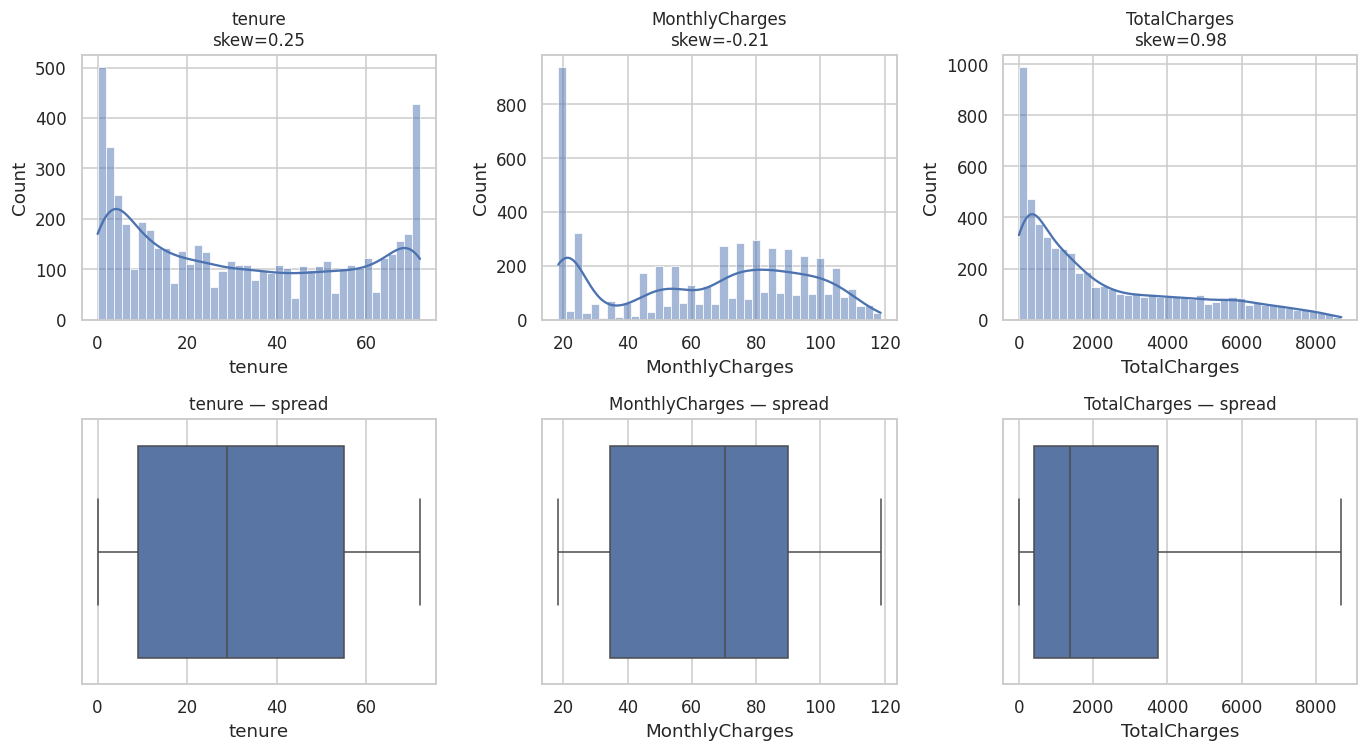

In [6]:
fig, axes = plt.subplots(2, len(NUM_COLS), figsize=(4.2 * len(NUM_COLS), 7))
for j, c in enumerate(NUM_COLS):
    sns.histplot(X[c], kde=True, ax=axes[0, j], bins=40)
    axes[0, j].set_title(f"{c}\nskew={X[c].skew():.2f}")
    sns.boxplot(x=X[c], ax=axes[1, j])
    axes[1, j].set_title(f"{c} — spread")
plt.tight_layout()
plt.show()

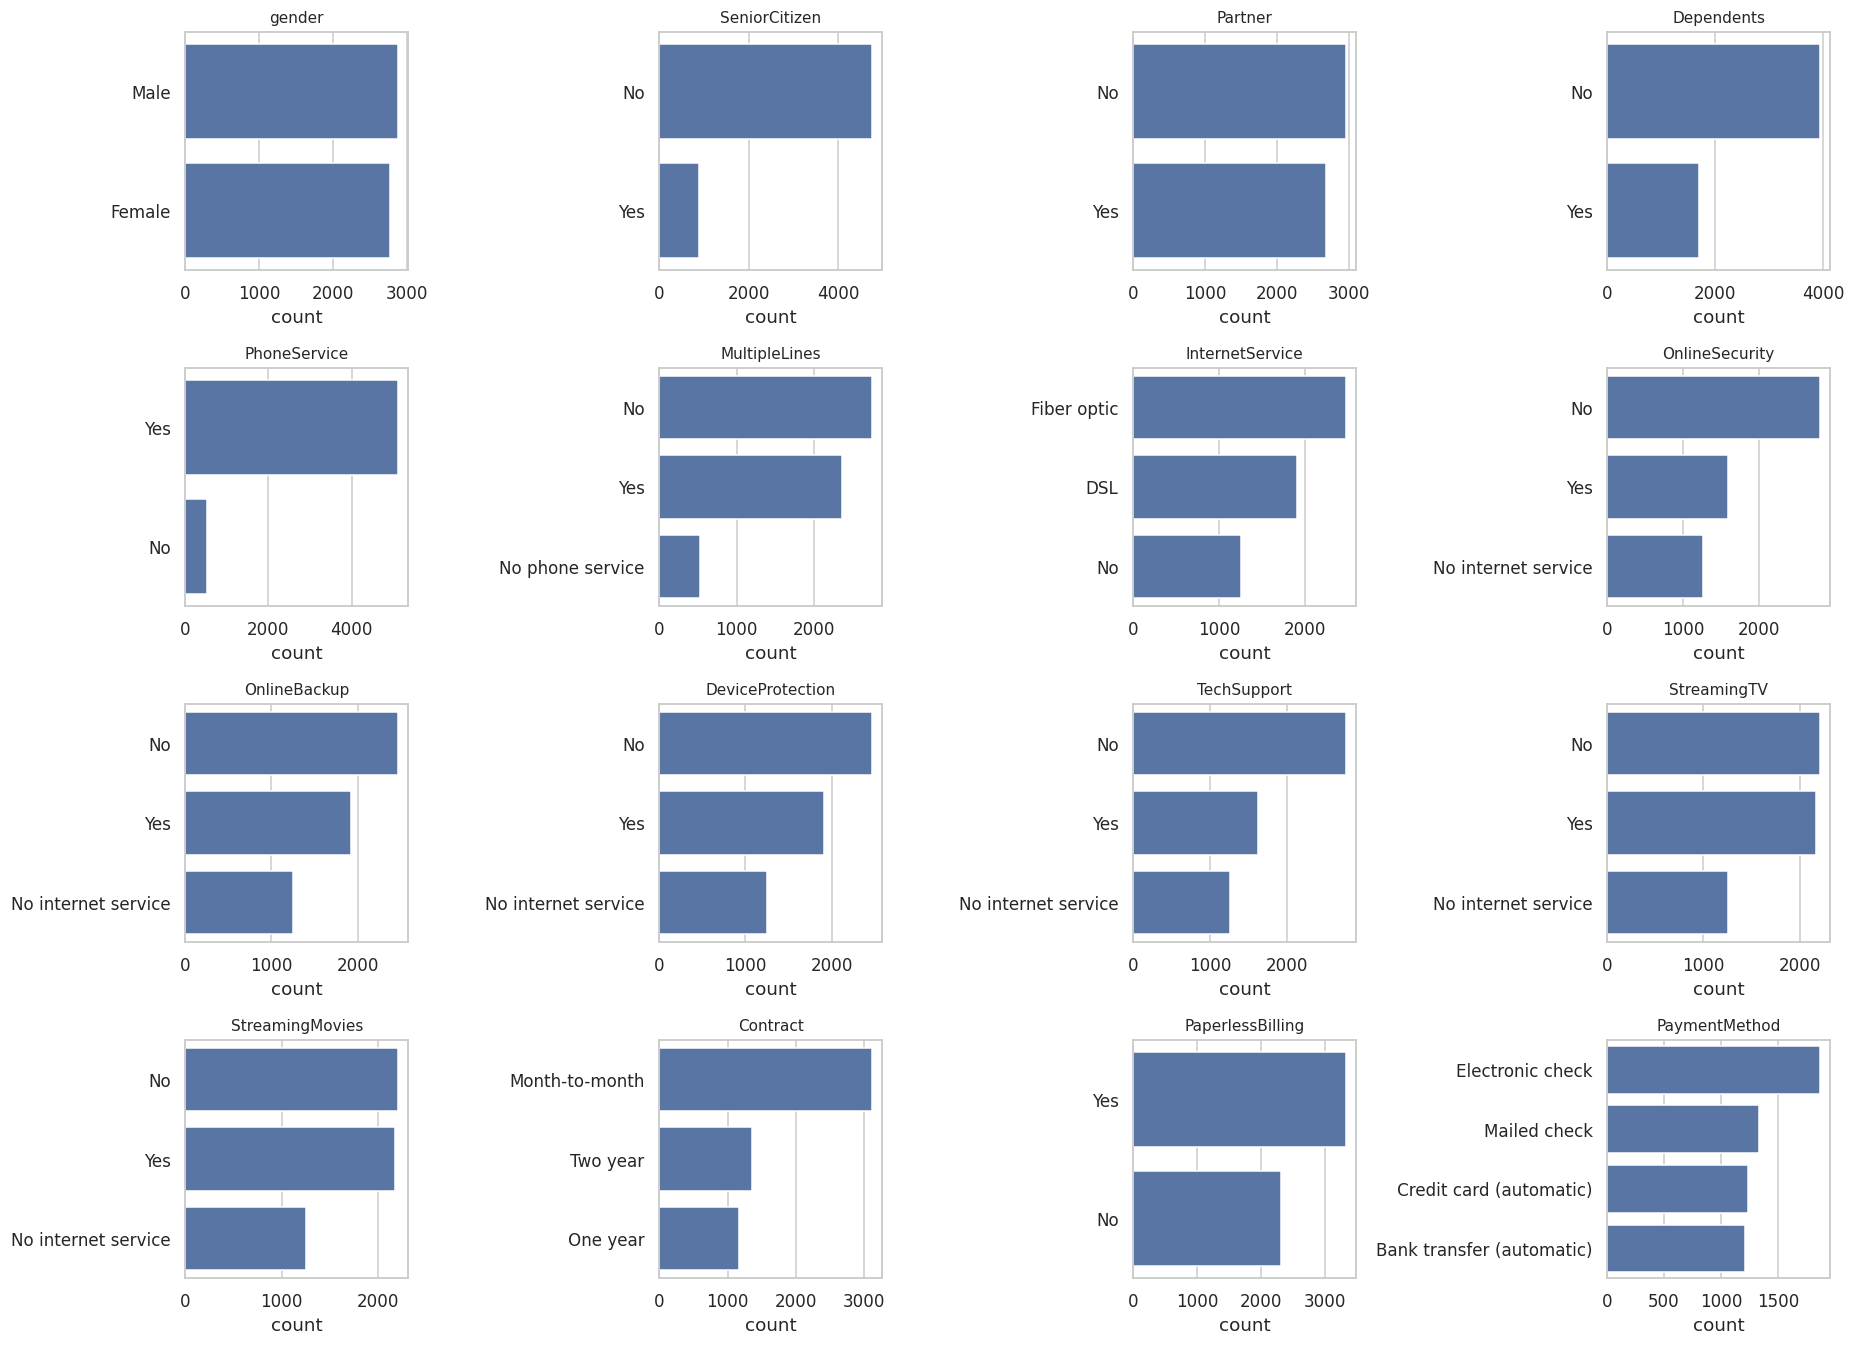

In [7]:
n = len(CAT_COLS)
fig, axes = plt.subplots((n + 3) // 4, 4, figsize=(17, 3.1 * ((n + 3) // 4)))
for ax, c in zip(axes.ravel(), CAT_COLS):
    order = X[c].value_counts().index
    sns.countplot(y=X[c], order=order, ax=ax)
    ax.set_title(c, fontsize=10)
    ax.set_ylabel("")
for ax in axes.ravel()[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [8]:
# Levels holding a tiny share of rows produce unstable estimates and encoding noise.
rare = []
for c in CAT_COLS:
    vc = X[c].value_counts(normalize=True)
    for level, share in vc.items():
        if share < 0.05:
            rare.append({"column": c, "level": level, "share_%": round(share * 100, 2),
                         "n": int((X[c] == level).sum())})
print("Levels below 5% of rows:")
display(pd.DataFrame(rare) if rare else "none")

Levels below 5% of rows:


'none'

### The redundant-service levels

Six service columns carry `No internet service`, and `MultipleLines` carries `No phone service`. That information already exists in `InternetService == "No"` and `PhoneService == "No"`, so the third level is pure redundancy — it inflates one-hot dimensionality and splits what is really a single binary signal across two columns.

Collapsing them to `"No"` is feature engineering, not cleaning, so it belongs in notebook 03 where its effect on the baseline can be measured. Recorded here as a hypothesis, not applied.

In [9]:
svc = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
       "TechSupport", "StreamingTV", "StreamingMovies"]

redundancy = pd.DataFrame({
    "no_internet_service": [(X[c] == "No internet service").sum() for c in svc],
}, index=svc)
redundancy["matches_InternetService_No"] = [
    int(((X[c] == "No internet service") == (X["InternetService"] == "No")).all())
    for c in svc
]
display(redundancy)

print(f"MultipleLines 'No phone service' rows : {(X['MultipleLines'] == 'No phone service').sum()}")
print(f"PhoneService == 'No' rows             : {(X['PhoneService'] == 'No').sum()}")
print("\nA 1 in the match column means the level is perfectly determined by "
      "InternetService and therefore carries no independent information.")

,no_internet_service,matches_InternetService_No
OnlineSecurity,1254,1
OnlineBackup,1254,1
DeviceProtection,1254,1
TechSupport,1254,1
StreamingTV,1254,1
StreamingMovies,1254,1


MultipleLines 'No phone service' rows : 532
PhoneService == 'No' rows             : 532

A 1 in the match column means the level is perfectly determined by InternetService and therefore carries no independent information.


---

## 3. Outlier Detection

Two methods, because they answer different questions. Boxplots show shape; IQR and Z-score give a defensible cutoff. The decision that matters afterwards is whether each outlier is an *error to remove* or a *real extreme to keep*.

In [10]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

rows = []
for c in NUM_COLS:
    lo, hi = iqr_bounds(X[c])
    iqr_out = ((X[c] < lo) | (X[c] > hi)).sum()
    z = np.abs(stats.zscore(X[c]))
    rows.append({
        "feature": c,
        "iqr_lower": round(lo, 2), "iqr_upper": round(hi, 2),
        "iqr_outliers": int(iqr_out), "iqr_%": round(100 * iqr_out / len(X), 2),
        "z>3": int((z > 3).sum()), "z>3_%": round(100 * (z > 3).mean(), 2),
        "observed_min": X[c].min(), "observed_max": X[c].max(),
    })
display(pd.DataFrame(rows))

,feature,iqr_lower,iqr_upper,iqr_outliers,iqr_%,z>3,z>3_%,observed_min,observed_max
0,tenure,-60.00,124.00,0,0.0,0,0.0,0.0,72.00
1,MonthlyCharges,-48.15,172.65,0,0.0,0,0.0,18.4,118.75
2,TotalCharges,-4592.34,8745.01,0,0.0,0,0.0,0.0,8684.80


### Outlier decisions

Every numeric feature here is bounded by business reality rather than by measurement error, which changes the verdict.

`tenure` runs 0 to 72 months because the snapshot covers six years of customers. A 72-month customer is not an anomaly, it is the most loyal segment. `MonthlyCharges` spans roughly 18 to 119 because that is the price range of the actual product catalogue. `TotalCharges` is skewed by construction, since it is approximately `tenure × MonthlyCharges` and both factors are bounded.

**Decision: remove nothing.** No value here is impossible, and every extreme is a real customer whose churn behaviour we need to predict. What the skew does affect is *model choice* — linear models will need the scaling and possibly the transformation applied in notebook 03, while tree-based models are indifferent to monotone transformations of the inputs.

The one group worth flagging is `tenure == 0`, verified in notebook 01 as new customers who have never been billed.

In [11]:
zero_tenure = X["tenure"] == 0
print(f"tenure == 0 rows in train : {zero_tenure.sum()}")
if zero_tenure.any():
    print(f"churn rate among them     : {y[zero_tenure].mean():.2%}")
    print(f"churn rate overall        : {y.mean():.2%}")
    display(train.loc[zero_tenure, ["tenure", "MonthlyCharges", "TotalCharges",
                                    "Contract", TARGET]])
    print("\nThese customers cannot have churned yet, since churn is measured over a "
          "period they have not completed. They are legitimate rows but structurally "
          "different, and a model may learn 'tenure == 0 implies stay' as a rule that "
          "reflects the measurement window rather than customer behaviour.")

tenure == 0 rows in train : 9
churn rate among them     : 0.00%
churn rate overall        : 26.54%


,tenure,MonthlyCharges,TotalCharges,Contract,Churn
118,0,20.00,0.0,Two year,0
1876,0,61.90,0.0,Two year,0
1910,0,20.25,0.0,Two year,0
3427,0,80.85,0.0,Two year,0
3471,0,19.70,0.0,One year,0
3819,0,25.35,0.0,Two year,0
4286,0,19.85,0.0,Two year,0
4442,0,25.75,0.0,Two year,0
4892,0,52.55,0.0,Two year,0



These customers cannot have churned yet, since churn is measured over a period they have not completed. They are legitimate rows but structurally different, and a model may learn 'tenure == 0 implies stay' as a rule that reflects the measurement window rather than customer behaviour.


---

## 4. Bivariate Analysis

Each predictor against the target. Categorical against categorical uses churn rate rather than raw counts, because a level containing 3,000 customers and one containing 300 are not comparable on counts alone.

In [12]:
base_rate = y.mean()
rows = []
for c in CAT_COLS:
    g = train.groupby(c)[TARGET].agg(["mean", "size"])
    for level, (rate, size) in g.iterrows():
        rows.append({"feature": c, "level": level, "n": int(size),
                     "churn_rate": rate, "lift_vs_base": rate / base_rate})

biv = pd.DataFrame(rows).sort_values("churn_rate", ascending=False)
print(f"Base churn rate: {base_rate:.2%}\n")
print("Highest-risk levels:")
display(biv.head(12).round(4))
print("Lowest-risk levels:")
display(biv.tail(8).round(4))

Base churn rate: 26.54%

Highest-risk levels:


,feature,level,n,churn_rate,lift_vs_base
41,PaymentMethod,Electronic check,1864,0.4496,1.6942
34,Contract,Month-to-month,3106,0.4253,1.6028
14,InternetService,Fiber optic,2471,0.4197,1.5815
25,TechSupport,No,2755,0.4189,1.5786
16,OnlineSecurity,No,2791,0.4171,1.5717
3,SeniorCitizen,Yes,893,0.4110,1.5488
19,OnlineBackup,No,2463,0.3971,1.4964
22,DeviceProtection,No,2464,0.3933,1.4820
38,PaperlessBilling,Yes,3322,0.3353,1.2638
31,StreamingMovies,No,2204,0.3330,1.2550


Lowest-risk levels:


,feature,level,n,churn_rate,lift_vs_base
26,TechSupport,No internet service,1254,0.0742,0.2795
23,DeviceProtection,No internet service,1254,0.0742,0.2795
20,OnlineBackup,No internet service,1254,0.0742,0.2795
17,OnlineSecurity,No internet service,1254,0.0742,0.2795
15,InternetService,No,1254,0.0742,0.2795
29,StreamingTV,No internet service,1254,0.0742,0.2795
32,StreamingMovies,No internet service,1254,0.0742,0.2795
36,Contract,Two year,1364,0.0271,0.1022


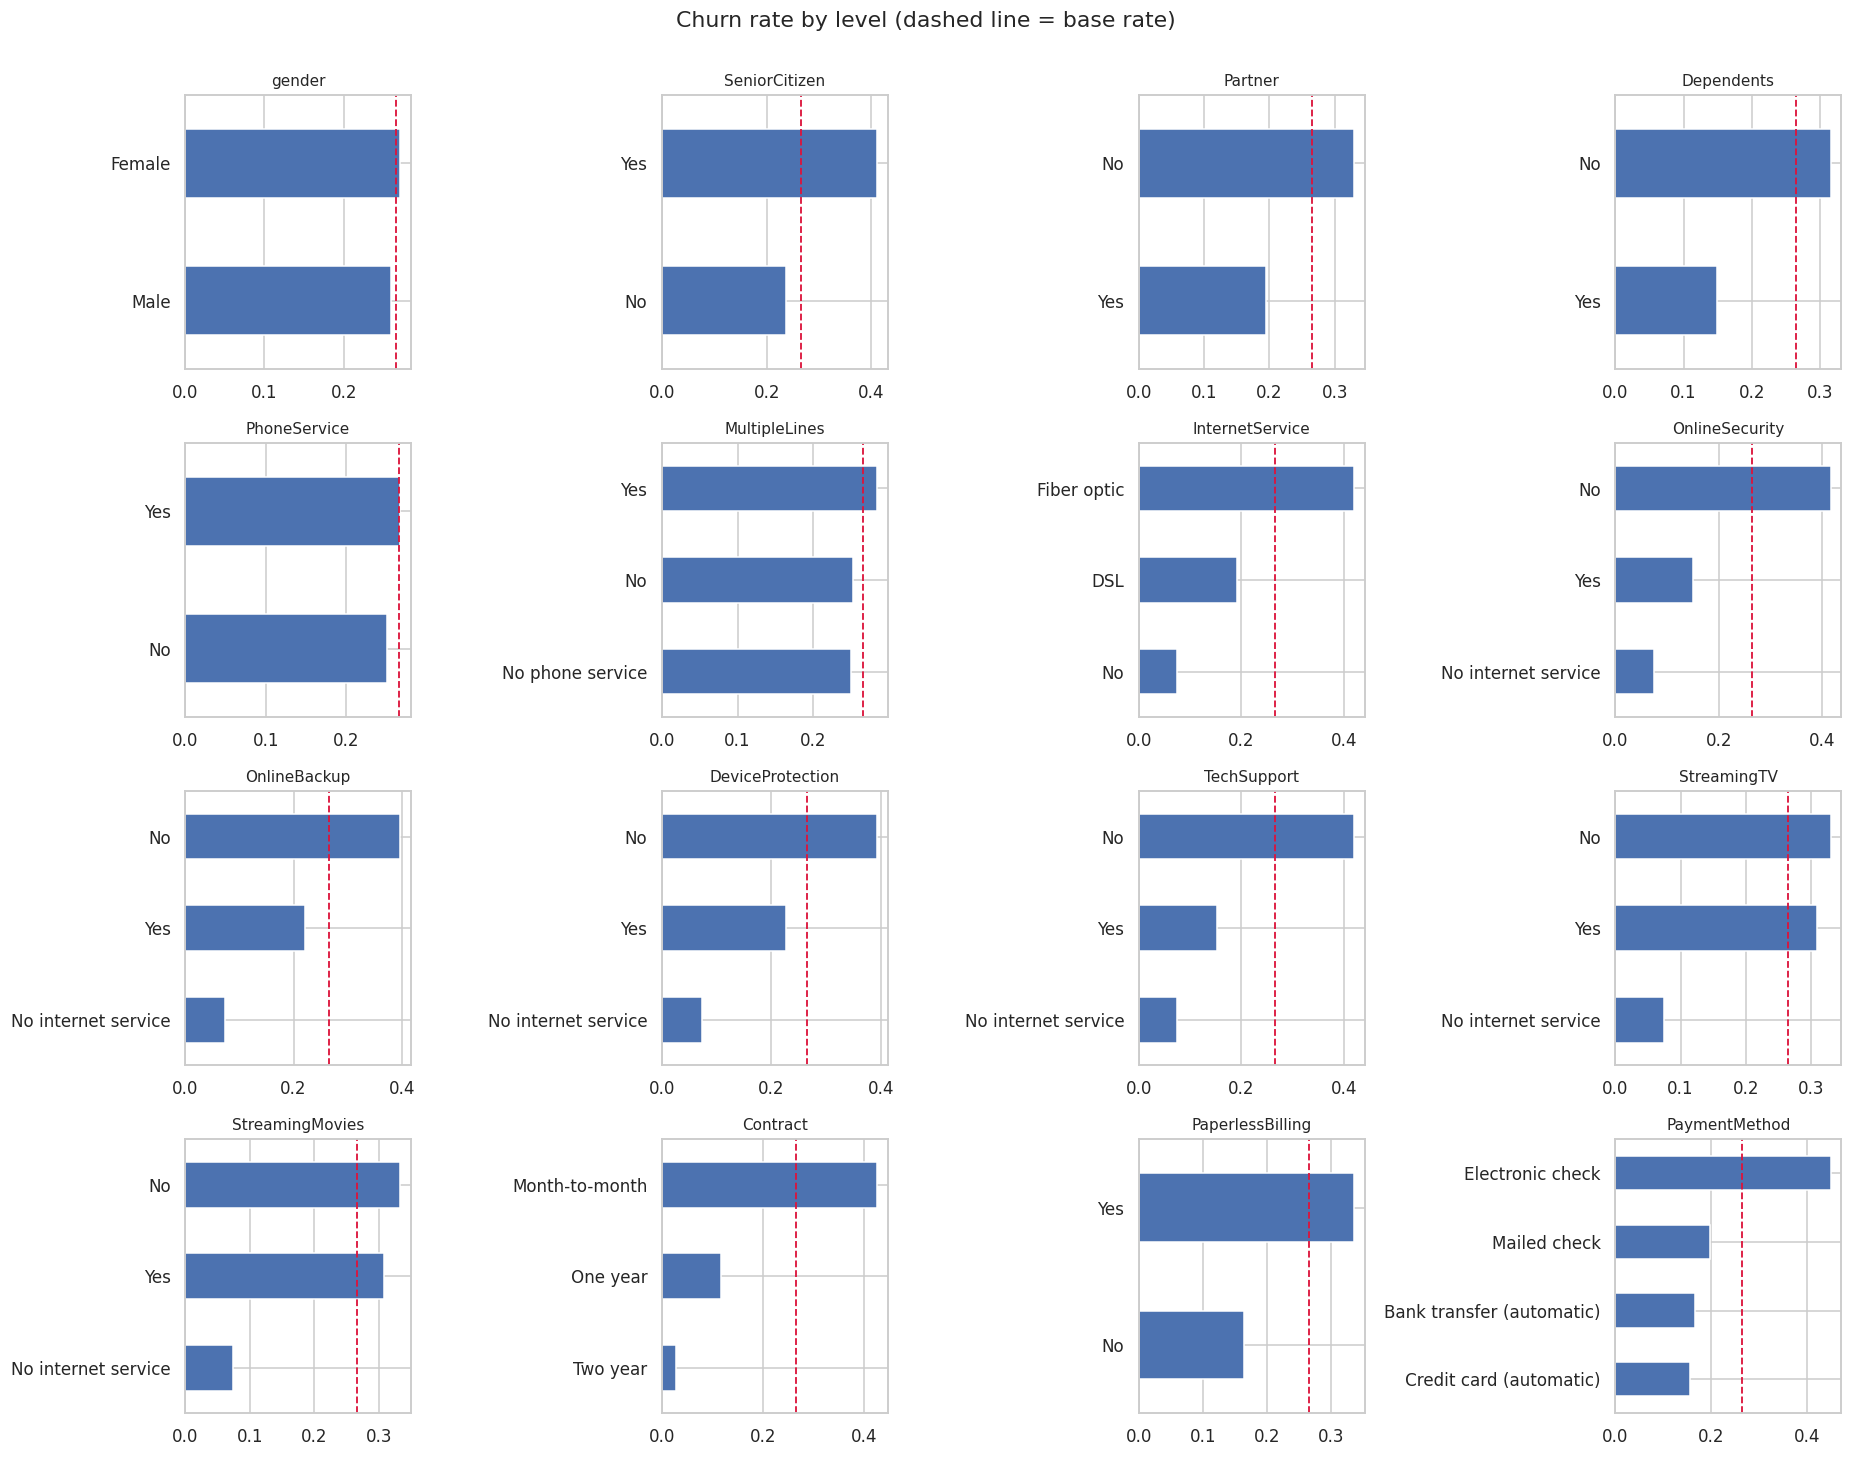

In [13]:
n = len(CAT_COLS)
fig, axes = plt.subplots((n + 3) // 4, 4, figsize=(17, 3.3 * ((n + 3) // 4)))
for ax, c in zip(axes.ravel(), CAT_COLS):
    g = train.groupby(c)[TARGET].mean().sort_values()
    g.plot(kind="barh", ax=ax)
    ax.axvline(base_rate, color="crimson", ls="--", lw=1.2)
    ax.set_title(c, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle("Churn rate by level (dashed line = base rate)", y=1.002)
plt.tight_layout()
plt.show()

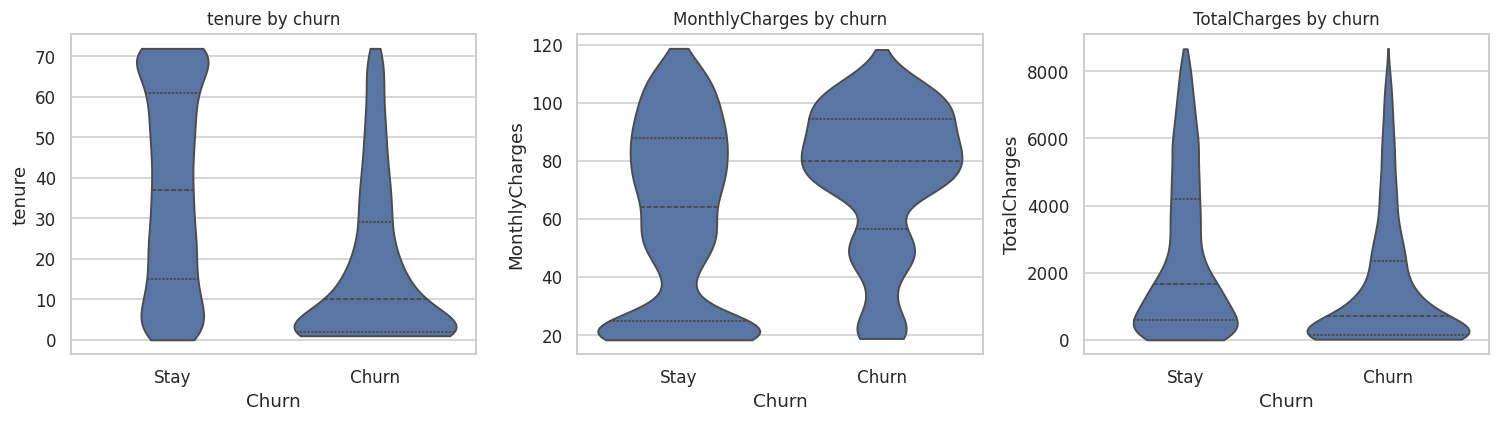

Mean by class:


tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
0      37.46   37.0          60.90  64.25      2522.82  1655.35
1      17.98   10.0          74.66  79.85      1545.18   706.60

In [14]:
fig, axes = plt.subplots(1, len(NUM_COLS), figsize=(4.6 * len(NUM_COLS), 4))
for ax, c in zip(np.atleast_1d(axes), NUM_COLS):
    sns.violinplot(data=train, x=TARGET, y=c, ax=ax, inner="quartile", cut=0)
    ax.set_title(f"{c} by churn")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Stay", "Churn"])
plt.tight_layout()
plt.show()

print("Mean by class:")
display(train.groupby(TARGET)[NUM_COLS].agg(["mean", "median"]).round(2))

In [15]:
# Effect size rather than a p-value. With 5,600 rows almost everything is
# "significant", so the question is not whether a difference exists but whether
# it is large enough to matter.
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled

eff = []
for c in NUM_COLS:
    a, b = train.loc[y == 1, c], train.loc[y == 0, c]
    d = cohens_d(a, b)
    eff.append({"feature": c, "cohens_d": round(d, 3),
                "magnitude": ("negligible" if abs(d) < 0.2 else
                              "small" if abs(d) < 0.5 else
                              "medium" if abs(d) < 0.8 else "large")})
display(pd.DataFrame(eff))

,feature,cohens_d,magnitude
0,tenure,-0.849,large
1,MonthlyCharges,0.465,small
2,TotalCharges,-0.441,small


---

## 5. Multivariate Analysis

Combinations invisible when looking at two features at a time.

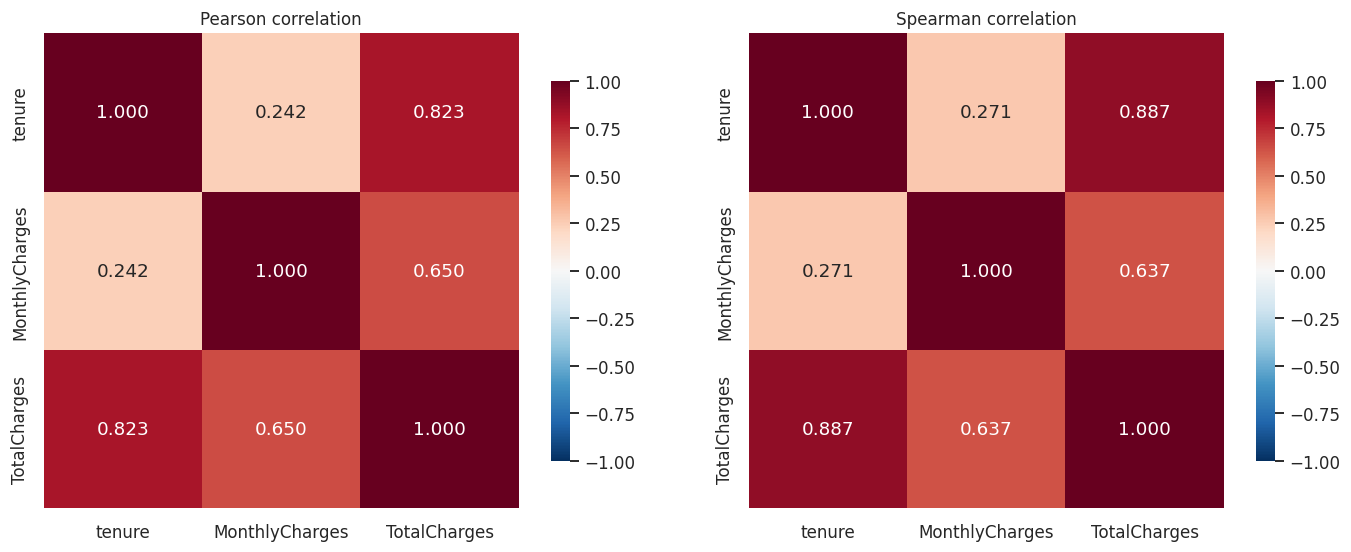

Pearson captures linear association; Spearman captures any monotonic one.
A large gap between them signals a non-linear but ordered relationship.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, method in zip(axes, ["pearson", "spearman"]):
    corr = X[NUM_COLS].corr(method=method)
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{method.capitalize()} correlation")
plt.tight_layout()
plt.show()

print("Pearson captures linear association; Spearman captures any monotonic one.")
print("A large gap between them signals a non-linear but ordered relationship.")

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_df = add_constant(X[NUM_COLS].astype(float))
vif = pd.DataFrame({
    "feature": vif_df.columns,
    "VIF": [variance_inflation_factor(vif_df.values, i) for i in range(vif_df.shape[1])],
}).query("feature != 'const'")
display(vif.round(2))

print("Rule of thumb: VIF above 5 is concerning, above 10 is severe.")
print("\nThis matters for linear models, where collinearity inflates coefficient")
print("variance and makes signs unstable and uninterpretable. Tree ensembles are")
print("unaffected in accuracy, but SHAP values still split credit arbitrarily")
print("between correlated features, so read attributions with that in mind.")

,feature,VIF
1,tenure,5.72
2,MonthlyCharges,3.20
3,TotalCharges,9.33


Rule of thumb: VIF above 5 is concerning, above 10 is severe.

This matters for linear models, where collinearity inflates coefficient
variance and makes signs unstable and uninterpretable. Tree ensembles are
unaffected in accuracy, but SHAP values still split credit arbitrarily
between correlated features, so read attributions with that in mind.


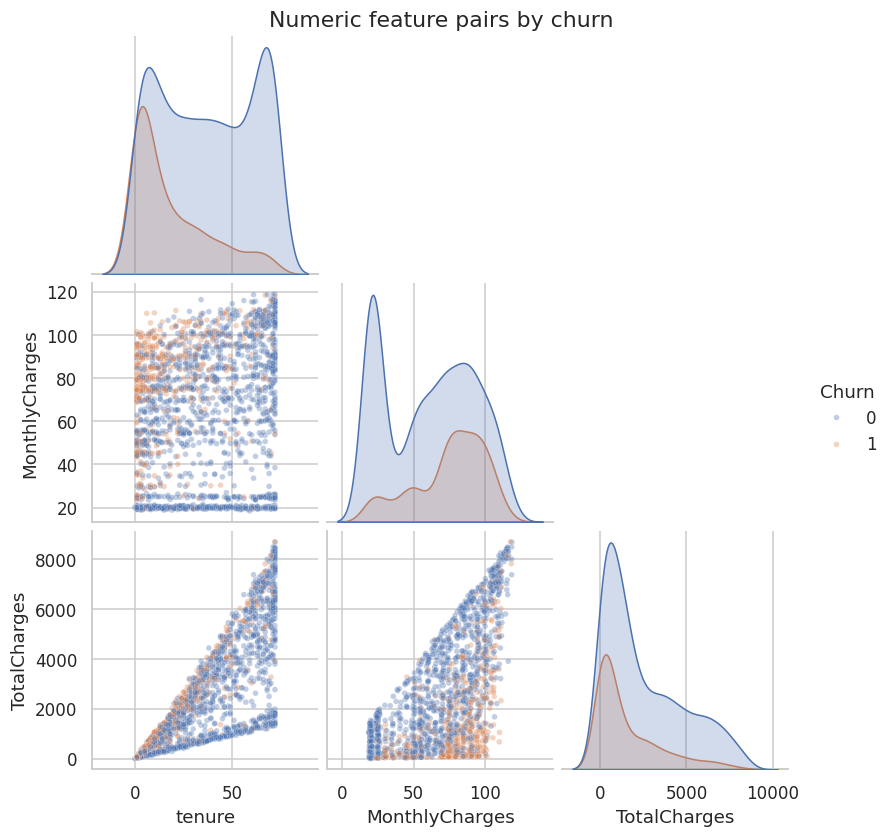

In [18]:
sample = train.sample(min(2000, len(train)), random_state=RANDOM_SEED)
g = sns.pairplot(sample[NUM_COLS + [TARGET]], hue=TARGET, corner=True,
                 plot_kws={"alpha": 0.35, "s": 14}, diag_kind="kde")
g.figure.suptitle("Numeric feature pairs by churn", y=1.01)
plt.show()

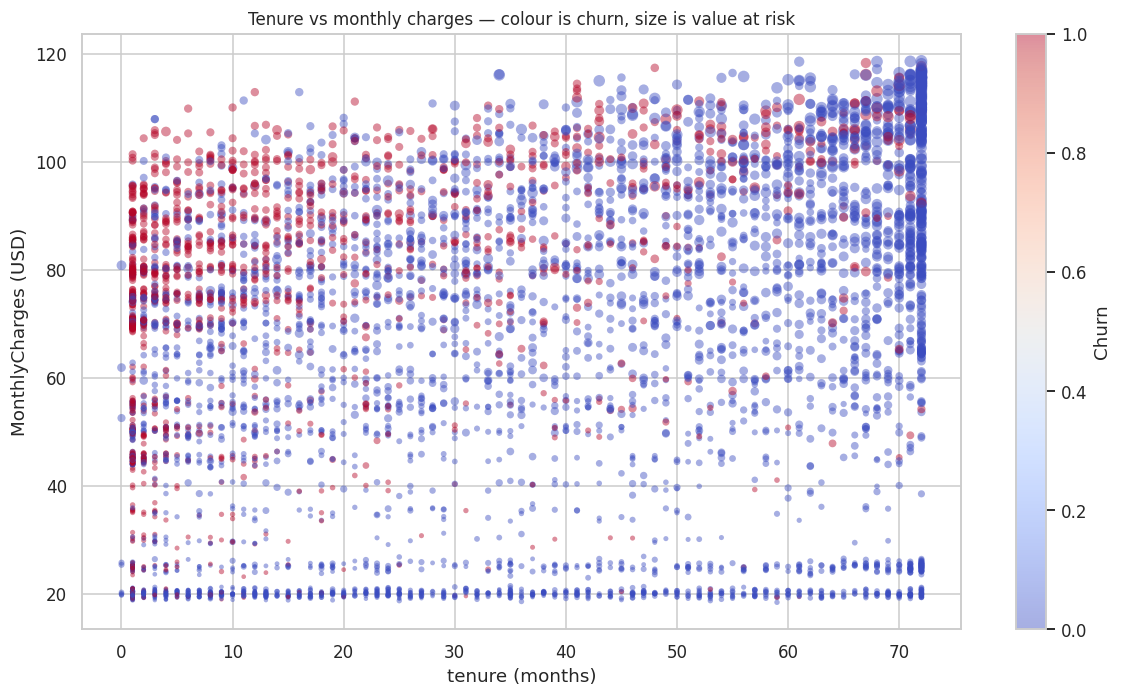

In [19]:
# Four variables at once: two numeric axes, colour for churn, size for value at risk.
fig, ax = plt.subplots(figsize=(11, 6.5))
v = value_at_risk(train["MonthlyCharges"], train["Contract"])
sc = ax.scatter(train["tenure"], train["MonthlyCharges"],
                c=train[TARGET], cmap="coolwarm", alpha=0.45,
                s=v / v.max() * 55 + 4, edgecolors="none")
ax.set_xlabel("tenure (months)")
ax.set_ylabel("MonthlyCharges (USD)")
ax.set_title("Tenure vs monthly charges — colour is churn, size is value at risk")
plt.colorbar(sc, label="Churn")
plt.tight_layout()
plt.show()

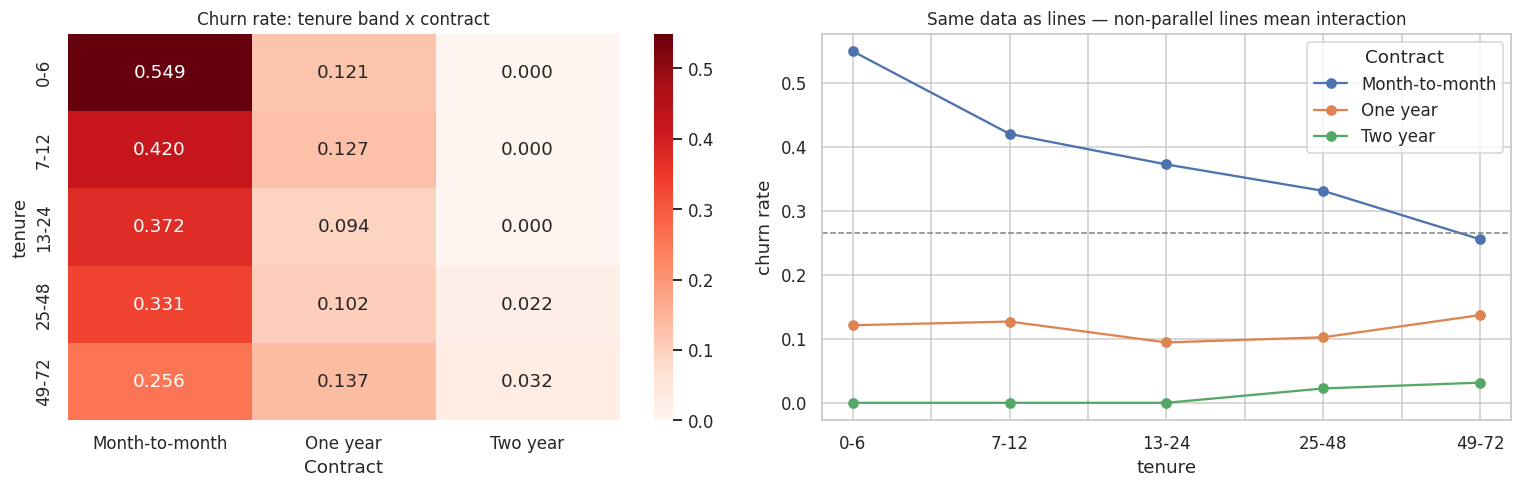

Contract,Month-to-month,One year,Two year
tenure,,,
0-6,0.5492,0.1212,0.0000
7-12,0.4202,0.1270,0.0000
13-24,0.3725,0.0943,0.0000
25-48,0.3312,0.1024,0.0224
49-72,0.2556,0.1370,0.0315


In [20]:
# The interaction most likely to matter: does tenure protect equally across contracts?
pivot = train.pivot_table(index=pd.cut(train["tenure"], [-0.1, 6, 12, 24, 48, 72],
                                       labels=["0-6", "7-12", "13-24", "25-48", "49-72"]),
                          columns="Contract", values=TARGET, aggfunc="mean", observed=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Reds", ax=axes[0])
axes[0].set_title("Churn rate: tenure band x contract")
pivot.plot(marker="o", ax=axes[1])
axes[1].axhline(base_rate, color="grey", ls="--", lw=1)
axes[1].set_title("Same data as lines — non-parallel lines mean interaction")
axes[1].set_ylabel("churn rate")
plt.tight_layout()
plt.show()
display(pivot.round(4))

---

## 6. Adversarial Validation

Train a classifier to tell training rows from test rows. An AUC near 0.5 means the two come from the same distribution. Substantially above 0.5 means they differ, and cross-validation scores will not predict test performance until you understand why.

**Boundary enforcement.** The cell below drops the target in the same expression that reads the file. No variable in this notebook holds a test label, so the transductive line stays intact by construction rather than by discipline.

**Expected result, stated before running.** The split in notebook 01 was a stratified random draw from a single snapshot, so train and test are samples from one population and AUC should land near 0.5. This test earns its place on projects with time-based splits or externally supplied test sets. Running it here is cheap insurance and confirms the split was implemented as designed.

In [21]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Target dropped inline: test labels never enter a variable in this notebook.
X_test_features = pd.read_parquet(find_artifact("test.parquet")).drop(columns=[TARGET])
assert TARGET not in X_test_features.columns
assert list(X_test_features.columns) == list(X.columns), "Column mismatch across split"

combined = pd.concat([X, X_test_features], ignore_index=True)
is_test = np.r_[np.zeros(len(X)), np.ones(len(X_test_features))]

for c in combined.select_dtypes(include="object").columns:
    combined[c] = combined[c].astype("category")

adv = cross_val_score(
    HistGradientBoostingClassifier(random_state=RANDOM_SEED, categorical_features="from_dtype"),
    combined, is_test,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED),
    scoring="roc_auc",
)
print(f"Adversarial AUC: {adv.mean():.4f} (sd {adv.std():.4f})  folds {np.round(adv, 4)}")
print("\n0.50-0.55 healthy | 0.55-0.70 investigate | >0.70 the split is not random")

del X_test_features, combined, is_test

Adversarial AUC: 0.4971 (sd 0.0193)  folds [0.5136 0.4831 0.5194 0.4675 0.5018]

0.50-0.55 healthy | 0.55-0.70 investigate | >0.70 the split is not random


---

## 7. Where the Money Is

Standard EDA ranks features by association with the target. That ranking answers the wrong question for this project, because the decision is not "who churns" but "where is contacting worth it".

A segment with a 45% churn rate and a 20 USD bill on a month-to-month contract is worth less than a segment with a 25% churn rate and a 100 USD bill on a two-year contract, since value at risk scales with both the bill and the remaining horizon. The analysis below ranks segments by **expected recoverable margin** rather than churn rate:

$$\text{recoverable}_s = n_s \times \text{churn rate}_s \times (\varepsilon \bar{V}_s - \bar{C}_s)$$

This is the quantity the retention team actually cares about, and it is what turns an EDA section into a business case.

In [22]:
work = train.copy()
work["V"] = value_at_risk(work["MonthlyCharges"], work["Contract"])
work["C"] = offer_cost(work["MonthlyCharges"])
work["p_star"] = optimal_threshold(work["MonthlyCharges"], work["Contract"])
work["breakeven_eps"] = breakeven_effectiveness(work["MonthlyCharges"], work["Contract"])

eps = COST_ASSUMPTIONS["offer_effectiveness"]

def segment_value(df, keys):
    g = df.groupby(keys, observed=False).agg(
        n=(TARGET, "size"),
        churn_rate=(TARGET, "mean"),
        mean_V=("V", "mean"),
        mean_C=("C", "mean"),
        mean_p_star=("p_star", "mean"),
    )
    g["gain_per_churner"] = eps * g["mean_V"] - g["mean_C"]
    g["recoverable_total"] = g["n"] * g["churn_rate"] * g["gain_per_churner"]
    g["share_of_recoverable_%"] = 100 * g["recoverable_total"] / g["recoverable_total"].sum()
    return g.sort_values("recoverable_total", ascending=False)

by_contract = segment_value(work, ["Contract"])
display(by_contract.round(3))

,n,churn_rate,mean_V,mean_C,mean_p_star,gain_per_churner,recoverable_total,share_of_recoverable_%
Contract,,,,,,,,
Month-to-month,3106,0.425,317.912,41.739,0.444,53.635,70851.376,79.165
One year,1164,0.118,468.641,41.053,0.299,99.539,13636.840,15.237
Two year,1364,0.027,578.527,38.158,0.226,135.400,5009.806,5.598


,,n,churn_rate,mean_V,mean_C,mean_p_star,gain_per_churner,recoverable_total,share_of_recoverable_%
Contract,InternetService,,,,,,,,
Month-to-month,Fiber optic,1706,0.54,417.85,54.23,0.43,71.12,66003.04,63.15
One year,Fiber optic,430,0.20,709.94,61.16,0.29,151.82,12904.68,12.35
Month-to-month,DSL,963,0.32,240.56,32.07,0.45,40.10,12430.60,11.89
Two year,Fiber optic,335,0.07,1007.45,64.97,0.22,237.27,5694.49,5.45
One year,DSL,443,0.10,443.52,38.96,0.29,94.10,4140.25,3.96
Two year,DSL,503,0.02,679.03,44.44,0.22,159.27,1751.98,1.68
Month-to-month,No,437,0.19,98.21,14.28,0.48,15.19,1260.52,1.21
One year,No,291,0.03,150.33,14.53,0.32,30.57,244.56,0.23
Two year,No,526,0.00,209.24,15.08,0.24,47.69,95.39,0.09


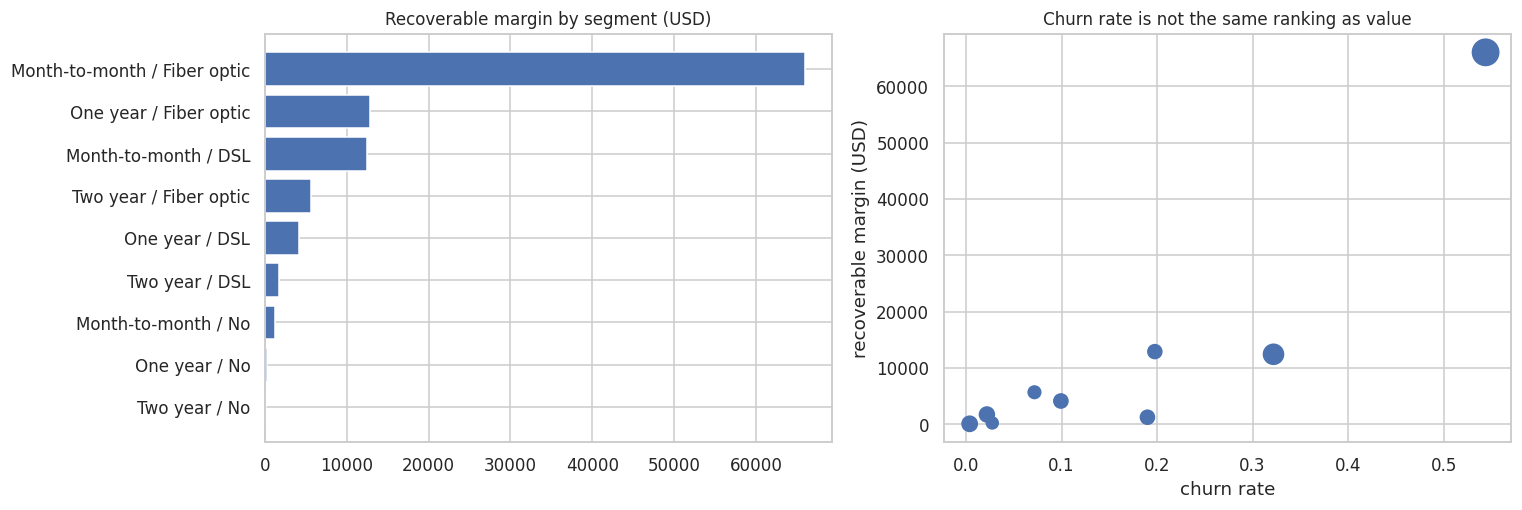

Spearman correlation between the two rankings: 0.833
Below ~0.9 means targeting by churn rate and targeting by value give
materially different customer lists.


In [23]:
seg = segment_value(work, ["Contract", "InternetService"])
display(seg.round(2).head(12))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
top = seg.head(9)
labels = [" / ".join(map(str, i)) for i in top.index]
axes[0].barh(labels, top["recoverable_total"])
axes[0].set_title("Recoverable margin by segment (USD)")
axes[0].invert_yaxis()
axes[1].scatter(seg["churn_rate"], seg["recoverable_total"], s=seg["n"] / 6 + 12)
axes[1].set_xlabel("churn rate"); axes[1].set_ylabel("recoverable margin (USD)")
axes[1].set_title("Churn rate is not the same ranking as value")
plt.tight_layout()
plt.show()

r_rank = seg["recoverable_total"].rank(ascending=False)
c_rank = seg["churn_rate"].rank(ascending=False)
print(f"Spearman correlation between the two rankings: "
      f"{stats.spearmanr(r_rank, c_rank).statistic:.3f}")
print("Below ~0.9 means targeting by churn rate and targeting by value give")
print("materially different customer lists.")

In [24]:
# Concentration: how much of the recoverable margin sits in the top segments?
cum = seg["recoverable_total"].cumsum() / seg["recoverable_total"].sum()
cov = seg["n"].cumsum() / seg["n"].sum()
conc = pd.DataFrame({"cum_recoverable_%": (100 * cum).round(1),
                     "cum_customers_%": (100 * cov).round(1)})
display(conc.head(8))
print("If a small share of customers holds most of the recoverable margin, a")
print("targeted campaign beats a broad one before any model exists — and that")
print("is the benchmark the model has to improve on.")

,,cum_recoverable_%,cum_customers_%
Contract,InternetService,,
Month-to-month,Fiber optic,63.1,30.3
One year,Fiber optic,75.5,37.9
Month-to-month,DSL,87.4,55.0
Two year,Fiber optic,92.8,61.0
One year,DSL,96.8,68.8
Two year,DSL,98.5,77.7
Month-to-month,No,99.7,85.5
One year,No,99.9,90.7


If a small share of customers holds most of the recoverable margin, a
targeted campaign beats a broad one before any model exists — and that
is the benchmark the model has to improve on.


---

## 8. Findings and Hypotheses

Recorded as testable claims, not conclusions. Each becomes a feature engineering experiment in notebook 03, where its effect on the baseline is measured rather than assumed.

In [25]:
findings = {
    "notebook": "02_eda",
    "train_rows": int(len(train)),
    "base_rate": round(float(base_rate), 5),
    "imbalance_ratio": round(float(ratio), 3),
    "resampling_decision": "none — distorts probabilities the cost threshold depends on",
    "outlier_decision": "remove none — all extremes are business-real, not measurement error",
    "numeric_skew": {c: round(float(X[c].skew()), 3) for c in NUM_COLS},
    "max_vif": round(float(vif["VIF"].max()), 2),
    "adversarial_auc": round(float(adv.mean()), 4),
    "top_lift_levels": biv.head(5)[["feature", "level", "churn_rate"]].to_dict("records"),
    "recoverable_by_contract": {
        str(k): round(float(v), 2) for k, v in by_contract["recoverable_total"].items()
    },
    "hypotheses": [
        "H1: collapsing 'No internet service' and 'No phone service' to 'No' reduces "
        "dimensionality without losing signal, since those levels are determined by "
        "InternetService and PhoneService",
        "H2: TotalCharges is near-redundant with tenure x MonthlyCharges; a ratio or "
        "residual feature may carry more information than the raw column",
        "H3: tenure and Contract interact — tenure protects unequally across contract "
        "types, so an explicit interaction term may help linear models",
        "H4: a count of subscribed add-on services may capture engagement better than "
        "six separate binary columns",
        "H5: tenure == 0 customers are structurally unable to have churned and may "
        "warrant an indicator flag",
    ],
}

(OUT_DIR / "eda_findings.json").write_text(json.dumps(findings, indent=2))
print(json.dumps(findings, indent=2))

{
  "notebook": "02_eda",
  "train_rows": 5634,
  "base_rate": 0.26535,
  "imbalance_ratio": 2.769,
  "resampling_decision": "none \u2014 distorts probabilities the cost threshold depends on",
  "outlier_decision": "remove none \u2014 all extremes are business-real, not measurement error",
  "numeric_skew": {
    "tenure": 0.249,
    "MonthlyCharges": -0.213,
    "TotalCharges": 0.982
  },
  "max_vif": 9.33,
  "adversarial_auc": 0.4971,
  "top_lift_levels": [
    {
      "feature": "PaymentMethod",
      "level": "Electronic check",
      "churn_rate": 0.44957081545064376
    },
    {
      "feature": "Contract",
      "level": "Month-to-month",
      "churn_rate": 0.4253058596265293
    },
    {
      "feature": "InternetService",
      "level": "Fiber optic",
      "churn_rate": 0.4196681505463375
    },
    {
      "feature": "TechSupport",
      "level": "No",
      "churn_rate": 0.4188747731397459
    },
    {
      "feature": "OnlineSecurity",
      "level": "No",
      "churn_ra

---

## Summary

| Question | Answer |
| :--- | :--- |
| Target balance | Mild imbalance; handle asymmetry at the threshold, not by resampling |
| Outliers | None removed — every extreme is a real customer, bounded by the product catalogue |
| Skew | Affects linear model preprocessing only; trees are indifferent |
| Collinearity | `TotalCharges` against `tenure` × `MonthlyCharges`; check the VIF figure above |
| Distribution shift | Adversarial AUC near 0.5 confirms the split behaved as designed |
| Highest churn rate | See the lift table in Part 4 |
| Highest recoverable margin | See Part 7 — a different ranking, and the one that matters |

**Carried into notebook 03:** five hypotheses in `eda_findings.json`, each to be tested against the baseline rather than adopted on the strength of a chart.

**What this notebook deliberately did not do:** no imputation values computed, no scaling fitted, no encoding decided. All of that belongs inside a pipeline that refits on every cross-validation fold. Computing it here, on the full training set, would leak fold-level information into the validation estimate — a smaller leak than touching the test set, and a far more common one.